# Multiple Liner Regression

## Build a model which will predict the profit that a startup company can have when Administraiton amount, R&D spend amount, Marlketting amount along with the state of the organization is specified.

### Collect Data and Perform EDA

In [59]:
import pandas as pd
import numpy as np

In [60]:
data = pd.read_csv("50_Startups.csv")

In [61]:
data.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [62]:
data.shape

(50, 5)

In [63]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


## #finding outliers

In [64]:
import matplotlib.pyplot as plt

<function matplotlib.pyplot.show(close=None, block=None)>

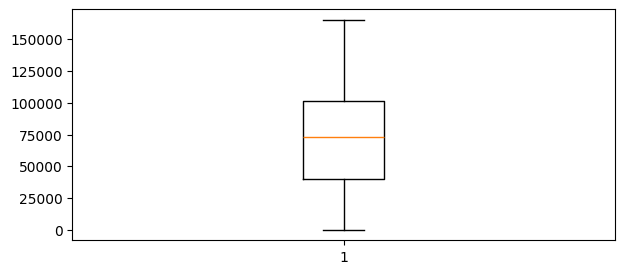

In [65]:
plt.figure(figsize=(7,3))
plt.boxplot(data["R&D Spend"])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

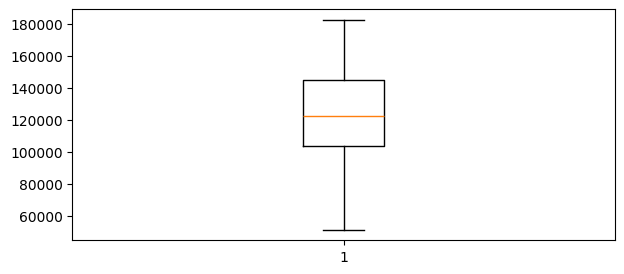

In [66]:
plt.figure(figsize=(7,3))
plt.boxplot(data["Administration"])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

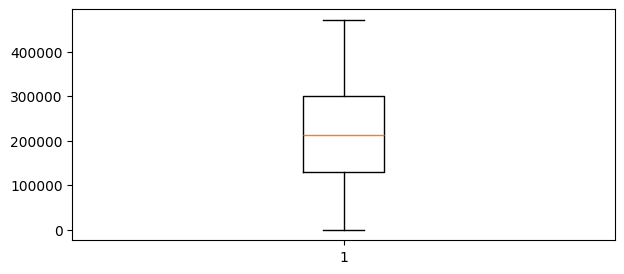

In [67]:
plt.figure(figsize=(7,3))
plt.boxplot(data["Marketing Spend"])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

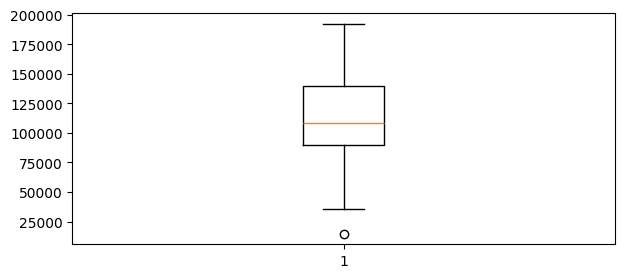

In [68]:
plt.figure(figsize=(7,3))
plt.boxplot(data["Profit"])
plt.show

## #Data Encoding

In [69]:
data["State"].value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

In [70]:
data = pd.get_dummies(data,columns = ["State"],dtype = "int")

In [71]:
data.head()

,R&D Spend,Administration,Marketing Spend,Profit,State_California,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,0,1
1,162597.70,151377.59,443898.53,191792.06,1,0,0
2,153441.51,101145.55,407934.54,191050.39,0,1,0
3,144372.41,118671.85,383199.62,182901.99,0,0,1
4,142107.34,91391.77,366168.42,166187.94,0,1,0


## #Split Data in Training and Testing

In [72]:
X = data.drop("Profit",axis = 1)
y = data["Profit"]

In [73]:
X.head()

,R&D Spend,Administration,Marketing Spend,State_California,State_Florida,State_New York
0,165349.20,136897.80,471784.10,0,0,1
1,162597.70,151377.59,443898.53,1,0,0
2,153441.51,101145.55,407934.54,0,1,0
3,144372.41,118671.85,383199.62,0,0,1
4,142107.34,91391.77,366168.42,0,1,0


## #Build model

In [74]:
from sklearn.model_selection import train_test_split

In [75]:
X_train, X_test,y_train,y_test = train_test_split(X,y, test_size = 0.3,random_state = 34)

In [76]:
from sklearn.linear_model import LinearRegression

In [77]:
lr = LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## #Check Acuuracy

In [78]:
test_predict = lr.predict(X_test)

In [80]:
from sklearn.metrics import r2_score,mean_absolute_percentage_error

In [81]:
print("test accuracy ", r2_score(y_test,test_predict))

test accuracy  0.9642233845164812


In [82]:
mean_absolute_percentage_error(y_test,test_predict)

0.08960450243245469

In [83]:
np.sqrt(mean_absolute_percentage_error(y_test,test_predict))

np.float64(0.2993401116329963)

In [84]:
## train accuracy: 

In [85]:
train_predict = lr.predict(X_train)

In [87]:
print("train accuracy ", r2_score(y_train,train_predict))

train accuracy  0.9260344143596423


##  #Deploy Model

In [97]:
coff = lr.coef_

In [89]:
intercept = lr.intercept_
intercept

np.float64(62591.7065416335)

In [90]:
r = 156000
a = 123000
m = 550000
state = {"California":0,"Florida":0,"New York":0}
s = "Florida"
state[s] = 1

In [91]:
# creating line opration 

In [92]:
profit = intercept + coff[0] * r + coff[1] * a + coff[2] * m + coff[3] * state["California"] + coff[4] * state["Florida"] + coff[5] *state["New York"]
print("predicted profit",profit)

predicted profit 181309.94003352502


In [93]:
# use predict method

In [94]:
lr.predict([[r,a,m,state['California'], state['Florida'],state['New York']]])

C:\Users\Dipak\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([181309.94003353])

## #Find and Visualize Correlation

In [95]:
import seaborn as sns

<Axes: >

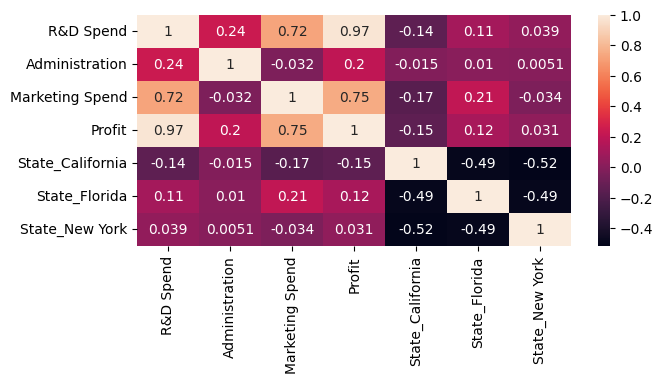

In [96]:
plt.figure(figsize=(7,3))
sns.heatmap(data.corr(),annot = True)